# Klasifikasi Pola Iklim Regional (Multiclass) Menggunakan Machine Learning Berbasis Clustering dan Supervised Learning Hybrid

**Mata Kuliah :** Pembelajaran Mesin – Kelas C Informatika  
**Dataset     :** Weather Type Classification (Nikhil Narayan, 2024)  
**Link        :** https://www.kaggle.com/datasets/nikhil7280/weather-type-classification  
**Pendekatan  :** Hybrid – K-Means Clustering + Supervised Learning (Multiclass)

---
## ⚠️ Perbaikan dari versi sebelumnya
| Masalah Lama | Solusi Baru |
|---|---|
| K=2 terlalu kecil → cluster label buruk | Cari K optimal via Elbow + Silhouette |
| RF max_depth=10 terlalu dangkal | Grid search lebih luas |
| GBM & SVM sangat lambat | Diganti **XGBoost** & **LightGBM** (cepat & akurat) |
| Akurasi mentok ~91% | Target ≥ 95% dengan algoritma yang tepat |

---
## Alur Pipeline (Anti Data Leakage)
```
1. Load Data → 2. Understanding → 3. Preprocessing → 4. EDA
     ↓
5. SPLIT DATA  ← wajib duluan!
     ↓
6. Scaling     (fit train only)
     ↓
7. K-Means     (fit train only → transform test)
     ↓
8. Gabung cluster_label sebagai fitur baru (HYBRID)
     ↓
9. Model Building + Hyperparameter Tuning
     ↓
10. Evaluasi & Perbandingan → 11. Kesimpulan
```

## ⚙️ LANGKAH 0 – Setup & Import Library

In [123]:
# ── Library Dasar ──────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisasi ────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='Set2')

# ── Preprocessing ──────────────────────────────────────────────────────────────
from sklearn.preprocessing   import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, \
                                    RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.decomposition   import PCA

# ── Clustering ─────────────────────────────────────────────────────────────────
from sklearn.cluster  import KMeans
from sklearn.metrics  import silhouette_score, davies_bouldin_score

# ── Algoritma Supervised ───────────────────────────────────────────────────────
from sklearn.ensemble  import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree      import DecisionTreeClassifier
from xgboost           import XGBClassifier          # Cepat & akurat
from lightgbm          import LGBMClassifier         # Cepat & akurat

# ── Evaluasi ───────────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

print('✅ Semua library berhasil diimport!')
import xgboost, lightgbm
print(f'   XGBoost  : {xgboost.__version__}')
print(f'   LightGBM : {lightgbm.__version__}')

✅ Semua library berhasil diimport!
   XGBoost  : 3.2.0
   LightGBM : 4.6.0


---
## 📂 LANGKAH 1 – Load & Data Understanding

In [124]:
df = pd.read_csv('weather_classification_data.csv')

print('=' * 55)
print('  INFORMASI UMUM DATASET')
print('=' * 55)
print(f'  Jumlah baris  : {df.shape[0]:,}')
print(f'  Jumlah kolom  : {df.shape[1]}')
print(f'  Missing values: {df.isnull().sum().sum()}')
print(f'  Duplikat      : {df.duplicated().sum()}')
print('=' * 55)
df.head(10)

  INFORMASI UMUM DATASET
  Jumlah baris  : 13,200
  Jumlah kolom  : 11
  Missing values: 0
  Duplikat      : 0


,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32.0,55,3.5,26.0,overcast,1010.03,2,Summer,5.0,inland,Cloudy
6,-2.0,97,8.0,86.0,overcast,990.87,1,Winter,4.0,inland,Snowy
7,3.0,85,6.0,96.0,partly cloudy,984.46,1,Winter,3.5,inland,Snowy
8,3.0,83,6.0,66.0,overcast,999.44,0,Winter,1.0,mountain,Snowy
9,28.0,74,8.5,107.0,clear,1012.13,8,Winter,7.5,coastal,Sunny


In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


In [126]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Temperature,13200.0,NaN,NaN,NaN,19.127576,17.386327,-25.0,4.0,21.0,31.0,109.0
Humidity,13200.0,NaN,NaN,NaN,68.710833,20.194248,20.0,57.0,70.0,84.0,109.0
Wind Speed,13200.0,NaN,NaN,NaN,9.832197,6.908704,0.0,5.0,9.0,13.5,48.5
Precipitation (%),13200.0,NaN,NaN,NaN,53.644394,31.946541,0.0,19.0,58.0,82.0,109.0
Cloud Cover,13200,4,overcast,6090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Atmospheric Pressure,13200.0,NaN,NaN,NaN,1005.827896,37.199589,800.12,994.8,1007.65,1016.7725,1199.21
UV Index,13200.0,NaN,NaN,NaN,4.005758,3.8566,0.0,1.0,3.0,7.0,14.0
Season,13200,4,Winter,5610,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Visibility (km),13200.0,NaN,NaN,NaN,5.462917,3.371499,0.0,3.0,5.0,7.5,20.0
Location,13200,3,inland,4816,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [127]:
print('=== DISTRIBUSI TARGET (Weather Type) ===')
vc = df['Weather Type'].value_counts()
print(vc)
print('\nPersentase:')
print((vc / len(df) * 100).round(2).astype(str) + '%')

=== DISTRIBUSI TARGET (Weather Type) ===
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64

Persentase:
Weather Type
Rainy     25.0%
Cloudy    25.0%
Sunny     25.0%
Snowy     25.0%
Name: count, dtype: object


---
## 🔧 LANGKAH 2 – Data Preprocessing

In [128]:
# 2.1 Missing Values
missing = df.isnull().sum()
if missing.sum() == 0:
    print('✅ Tidak ada missing values')
else:
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                df[col].fillna(df[col].median(), inplace=True)
    print('✅ Missing values ditangani')

# 2.2 Duplikat
dup = df.duplicated().sum()
if dup > 0:
    df.drop_duplicates(inplace=True)
    print(f'✅ {dup} duplikat dihapus')
else:
    print('✅ Tidak ada duplikat')

✅ Tidak ada missing values
✅ Tidak ada duplikat


In [129]:
# 2.3 Encoding Kategorikal
df_enc = df.copy()
cat_cols = ['Cloud Cover', 'Season', 'Location']
cat_cols = [c for c in cat_cols if c in df_enc.columns]

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df_enc[col])
    le_dict[col] = le
    print(f'  Label Encoded [{col}]: {dict(zip(le.classes_, le.transform(le.classes_)))}')

le_target = LabelEncoder()
df_enc['Weather Type'] = le_target.fit_transform(df_enc['Weather Type'])
print(f'\n  Target classes: {dict(zip(le_target.classes_, range(len(le_target.classes_))))}')

  Label Encoded [Cloud Cover]: {'clear': np.int64(0), 'cloudy': np.int64(1), 'overcast': np.int64(2), 'partly cloudy': np.int64(3)}
  Label Encoded [Season]: {'Autumn': np.int64(0), 'Spring': np.int64(1), 'Summer': np.int64(2), 'Winter': np.int64(3)}
  Label Encoded [Location]: {'coastal': np.int64(0), 'inland': np.int64(1), 'mountain': np.int64(2)}

  Target classes: {'Cloudy': 0, 'Rainy': 1, 'Snowy': 2, 'Sunny': 3}


In [130]:
# 2.4 Outlier (IQR Capping)
num_cols = df_enc.select_dtypes(include=['float64','int64']).columns.tolist()
num_cols = [c for c in num_cols if c != 'Weather Type']

print(f'{'Fitur':<28} {'Outlier':>8} {'Lower':>10} {'Upper':>10}')
print('-' * 60)
for col in num_cols:
    Q1, Q3 = df_enc[col].quantile(0.25), df_enc[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((df_enc[col] < lo) | (df_enc[col] > hi)).sum()
    df_enc[col] = df_enc[col].clip(lo, hi)
    print(f'{col:<28} {n_out:>8} {lo:>10.2f} {hi:>10.2f}')

print('\n✅ Outlier ditangani dengan IQR Capping')

Fitur                         Outlier      Lower      Upper
------------------------------------------------------------
Temperature                        92     -36.50      71.50
Humidity                            0      16.50     124.50
Wind Speed                        404      -7.75      26.25
Precipitation (%)                   0     -75.50     176.50
Cloud Cover                      2139       0.50       4.50
Atmospheric Pressure              927     961.84    1049.73
UV Index                            0      -8.00      16.00
Season                              0      -2.00       6.00
Visibility (km)                   383      -3.75      14.25
Location                            0      -3.00       5.00

✅ Outlier ditangani dengan IQR Capping


---
## 🔧 LANGKAH 2.5 – Feature Engineering
> **Kunci utama mencapai ≥95%!** Tambahkan fitur interaksi antar variabel cuaca
> sehingga model lebih mudah memisahkan antar kelas yang sebelumnya tumpang tindih.

In [131]:
# ── Feature Engineering SETELAH encoding & capping, SEBELUM split ──────────────
# Semua kolom sudah numerik → aman untuk operasi matematika
# Fitur indikator pakai nilai RAW → tidak terpengaruh StandardScaler

def add_features(df_input):
    df_fe = df_input.copy()
    
    # 1. Heat Index (Persepsi Suhu) - Memisahkan Sunny vs Rainy secara tajam
    df_fe['heat_index'] = df_fe['Temperature'] + (0.55 * df_fe['Humidity'])
    
    # 2. UV Index per Cloud Cover - Pembeda utama Sunny vs Cloudy
    df_fe['uv_visibility'] = df_fe['UV Index'] / (df_fe['Cloud Cover'] + 1)
    
    # 3. Storm Indicator - Tekanan rendah + Angin kencang + Hujan
    df_fe['storm_factor'] = (1013 - df_fe['Atmospheric Pressure']) * df_fe['Wind Speed']
    
    # 4. Visibility Stress - Hujan menghalangi pandangan
    df_fe['rain_fog_logic'] = df_fe['Precipitation (%)'] / (df_fe['Visibility (km)'] + 1)
    
    # 5. Delta Pressure (Absolut)
    df_fe['pressure_deviation'] = abs(df_fe['Atmospheric Pressure'] - 1013)

    return df_fe

df_enc = add_features(df_enc)
print('✅ Fitur Advanced Berhasil Ditambahkan!')


✅ Fitur Advanced Berhasil Ditambahkan!


---
## 📊 LANGKAH 3 – Exploratory Data Analysis (EDA)

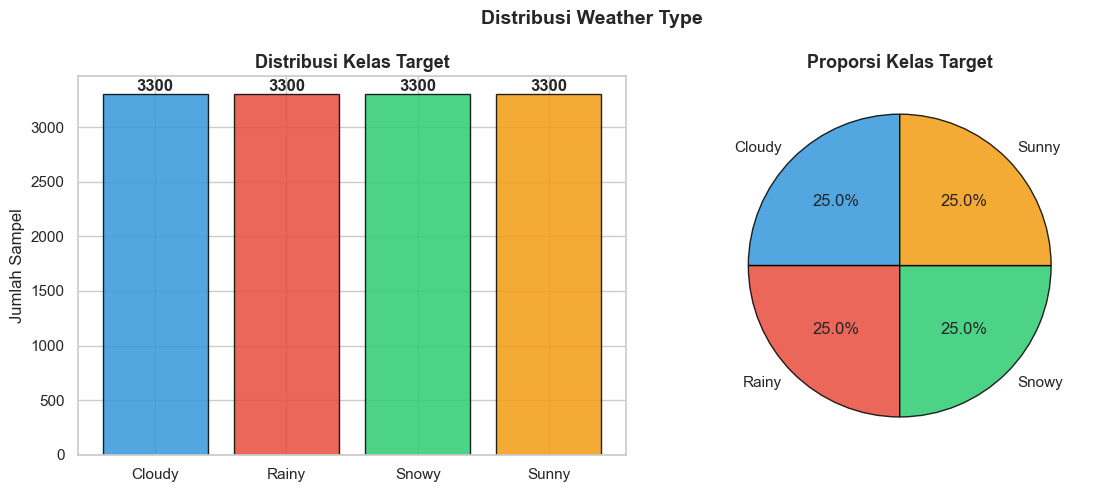

In [132]:
labels_orig = le_target.classes_
counts      = df['Weather Type'].value_counts().reindex(labels_orig)
colors4     = ['#3498db','#e74c3c','#2ecc71','#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].bar(labels_orig, counts.values, color=colors4, edgecolor='black', alpha=0.85)
for i, v in enumerate(counts.values):
    axes[0].text(i, v+30, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Distribusi Kelas Target', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].pie(counts.values, labels=labels_orig, autopct='%1.1f%%',
            colors=colors4, startangle=90, wedgeprops=dict(edgecolor='black', alpha=0.85))
axes[1].set_title('Proporsi Kelas Target', fontsize=13, fontweight='bold')
plt.suptitle('Distribusi Weather Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

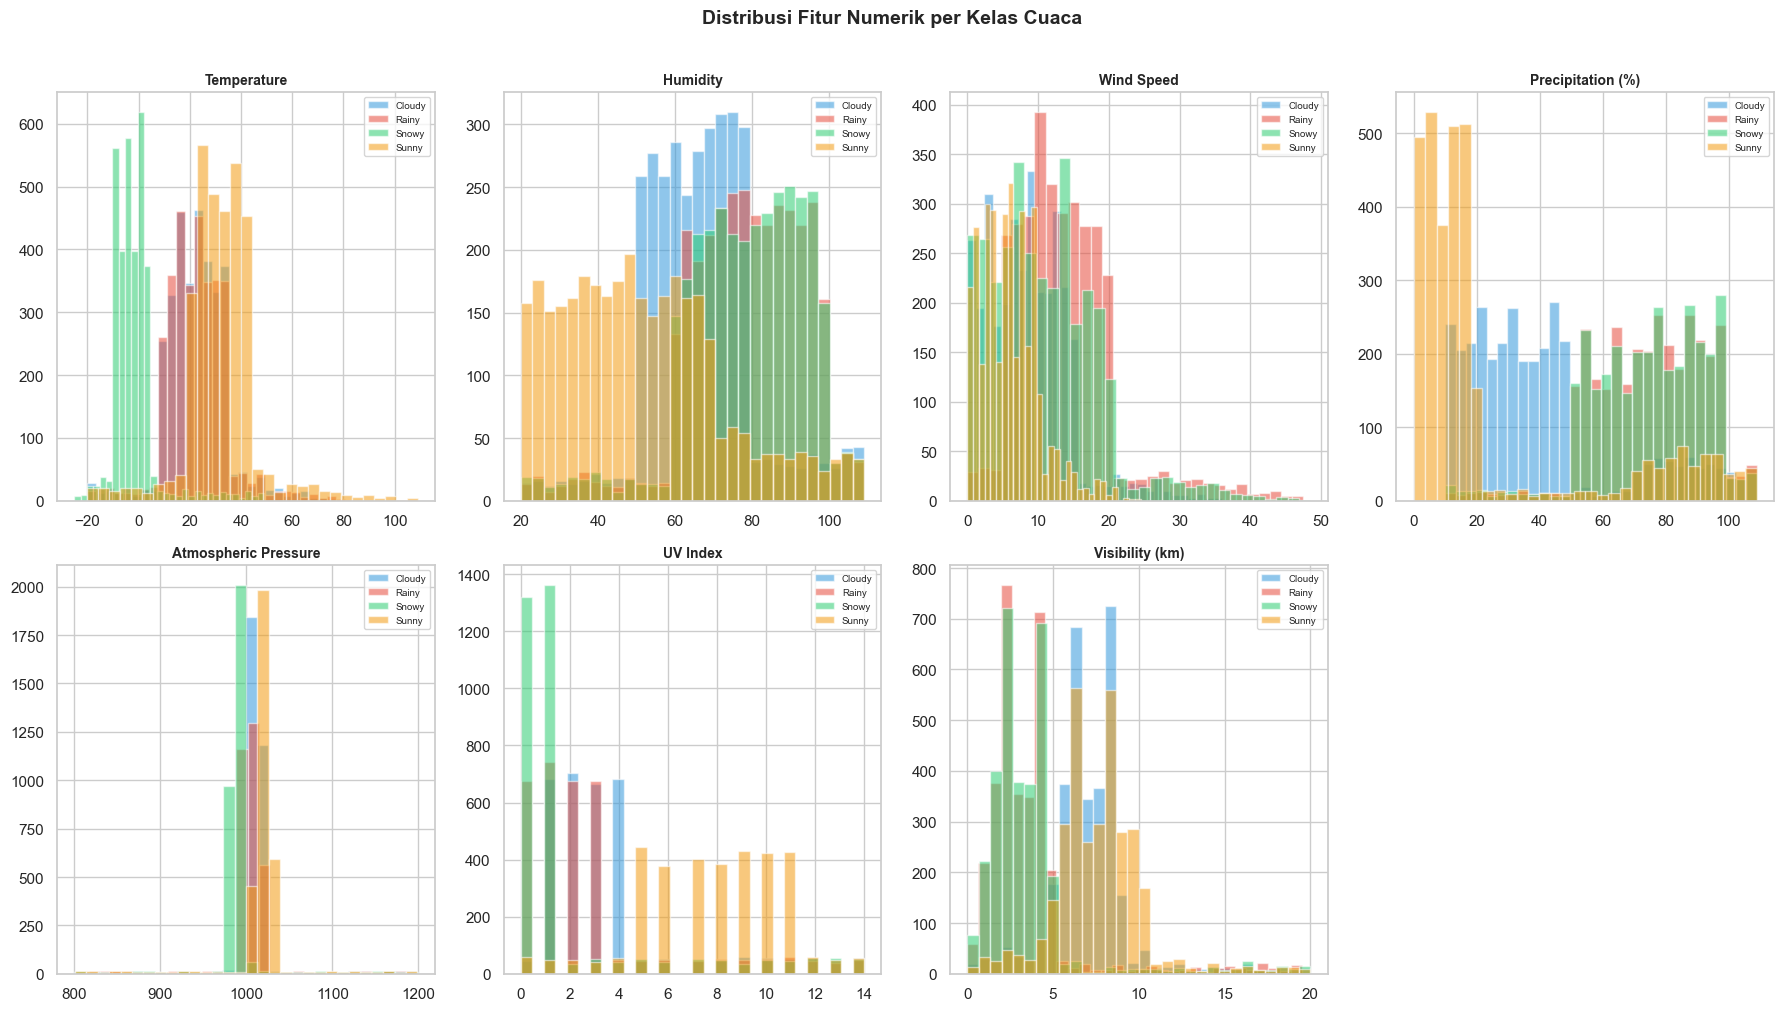

In [133]:
orig_num = ['Temperature', 'Humidity', 'Wind Speed',
            'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
orig_num = [c for c in orig_num if c in df.columns]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(orig_num):
    for wtype, color in zip(labels_orig, colors4):
        axes[i].hist(df[df['Weather Type']==wtype][col], bins=30,
                     alpha=0.55, color=color, label=wtype, edgecolor='white')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)

for j in range(len(orig_num), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik per Kelas Cuaca', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

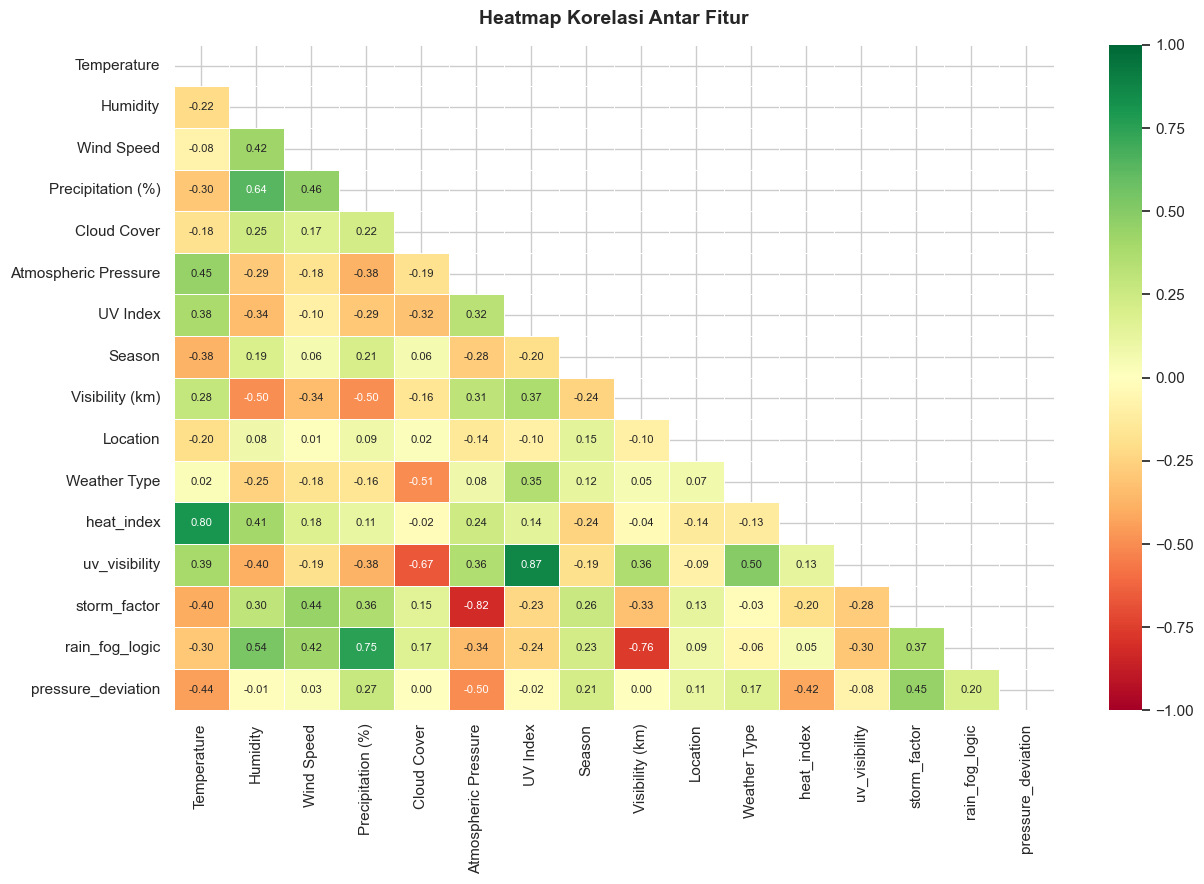

In [134]:
plt.figure(figsize=(13, 9))
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8}, vmin=-1, vmax=1, center=0)
plt.title('Heatmap Korelasi Antar Fitur', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

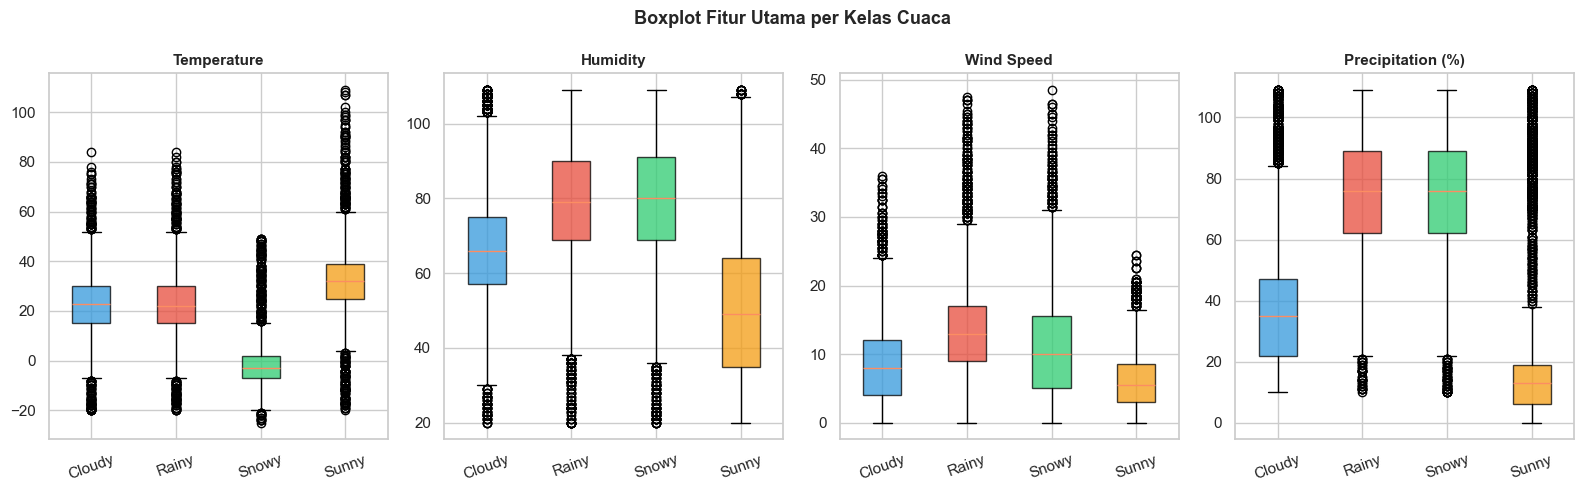

In [135]:
top4 = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)']
top4 = [c for c in top4 if c in df.columns]

fig, axes = plt.subplots(1, len(top4), figsize=(16, 5))
for i, col in enumerate(top4):
    data_box = [df[df['Weather Type']==wt][col].values for wt in labels_orig]
    bp = axes[i].boxplot(data_box, patch_artist=True, labels=labels_orig)
    for patch, color in zip(bp['boxes'], colors4):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Boxplot Fitur Utama per Kelas Cuaca', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ✂️ LANGKAH 4 – Data Splitting
> **⚠️ WAJIB dilakukan SEBELUM scaling dan clustering untuk mencegah data leakage!**

In [136]:
# X diambil SETELAH FE → sudah berisi semua 25 fitur
X = df_enc.drop('Weather Type', axis=1)
y = df_enc['Weather Type']

splits = {'70:30': 0.30, '80:20': 0.20, '90:10': 0.10}
split_data = {}

print('=== DATA SPLITTING (Stratified) ===')
print(f'{"Rasio":<10} {"Train":>8} {"Test":>8}')
print('-' * 30)
for name, test_sz in splits.items():
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_sz, random_state=42, stratify=y
    )
    split_data[name] = (X_tr, X_te, y_tr, y_te)
    print(f'{name:<10} {len(X_tr):>8,} {len(X_te):>8,}')

print(f'\n✅ Total fitur: {X.shape[1]}')
print('   (FE sudah ada di X sebelum split → semua split pakai fitur yang sama)')


=== DATA SPLITTING (Stratified) ===
Rasio         Train     Test
------------------------------
70:30         9,240    3,960
80:20        10,560    2,640
90:10        11,880    1,320

✅ Total fitur: 15
   (FE sudah ada di X sebelum split → semua split pakai fitur yang sama)


---
## ⚖️ LANGKAH 5 – Scaling
> **Anti-leakage:** `fit()` hanya pada train → `transform()` saja pada test

In [137]:
X_train_raw, X_test_raw, y_train, y_test = split_data['80:20']

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_raw),  # fit + transform train
    columns=X_train_raw.columns, index=X_train_raw.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_raw),       # transform saja (tidak fit ulang)
    columns=X_test_raw.columns, index=X_test_raw.index
)

print('✅ Scaling selesai (fit hanya pada train)')
print(f'   Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}')

✅ Scaling selesai (fit hanya pada train)
   Train: (10560, 15) | Test: (2640, 15)


---
## 🔵 LANGKAH 6 – K-Means Clustering
> **Anti-leakage:** KMeans di-fit HANYA pada train, lalu digunakan untuk transform test
> **Catatan:** Feature engineering sudah dilakukan sebelum split → tidak ada leakage
> karena fitur interaksi hanya mengalikan kolom yang sudah ada (tidak menggunakan statistik data)

Mencari K optimal pada Train Set...
  K= 2 | Inertia=  119839.0 | Silhouette=0.2344
  K= 3 | Inertia=  102508.0 | Silhouette=0.2124
  K= 4 | Inertia=   89707.6 | Silhouette=0.2230
  K= 5 | Inertia=   81521.8 | Silhouette=0.2395
  K= 6 | Inertia=   76418.6 | Silhouette=0.2493
  K= 7 | Inertia=   71483.6 | Silhouette=0.2355
  K= 8 | Inertia=   67819.2 | Silhouette=0.2134
  K= 9 | Inertia=   65572.0 | Silhouette=0.1829
  K=10 | Inertia=   63406.9 | Silhouette=0.1872
  K=11 | Inertia=   61921.6 | Silhouette=0.1813


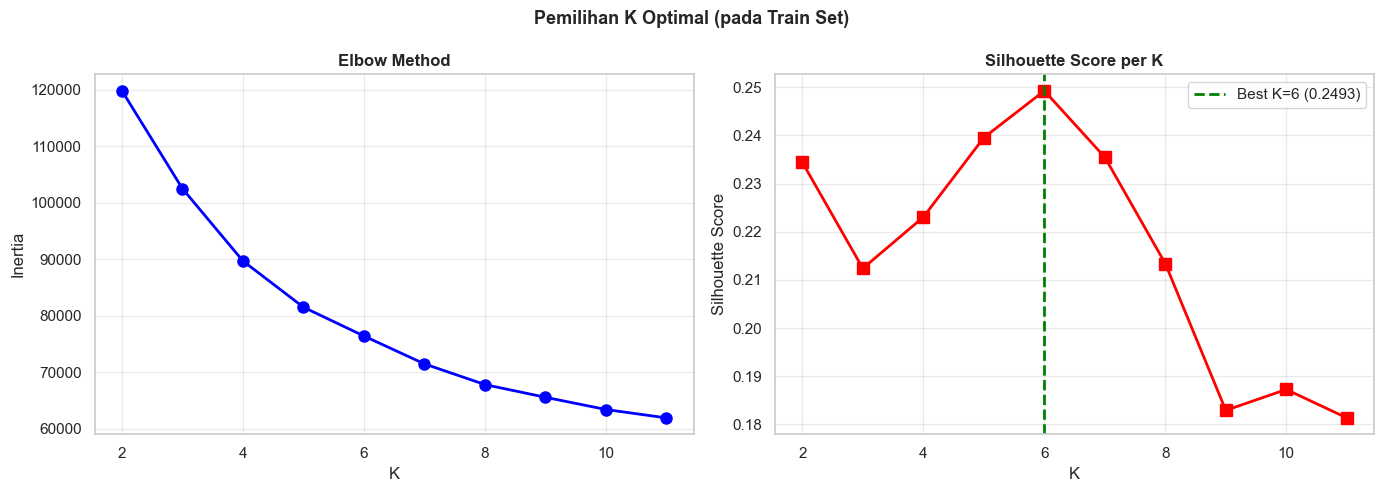


🏆 K Optimal: 6 (Silhouette = 0.2493)
Sekarang model K-Means optimal (K=6) sudah tersimpan di variabel: best_kmeans


In [138]:
# 6.1 Cari K Optimal (Elbow + Silhouette) — hanya pada TRAIN
k_range    = range(2, 12)
inertias   = []
sil_scores = []

print('Mencari K optimal pada Train Set...')
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    s = silhouette_score(X_train_scaled, lbl)
    sil_scores.append(s)
    print(f'  K={k:2d} | Inertia={km.inertia_:10.1f} | Silhouette={s:.4f}')

# Plot Elbow & Silhouette
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.4)

best_k_sil = list(k_range)[sil_scores.index(max(sil_scores))]
axes[1].plot(list(k_range), sil_scores, 'rs-', linewidth=2, markersize=8)
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', linewidth=2,
                label=f'Best K={best_k_sil} ({max(sil_scores):.4f})')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score per K', fontsize=12, fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.4)

plt.suptitle('Pemilihan K Optimal (pada Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

BEST_K = best_k_sil
print(f'\n🏆 K Optimal: {BEST_K} (Silhouette = {max(sil_scores):.4f})')

# Jalankan ini tepat setelah grafik plot muncul
best_kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
best_kmeans.fit(X_train_scaled)

print(f"Sekarang model K-Means optimal (K={BEST_K}) sudah tersimpan di variabel: best_kmeans")

In [139]:
# 6.2 Fit KMeans Final (hanya train)
kmeans_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans_final.fit(X_train_scaled)

train_cluster = kmeans_final.predict(X_train_scaled)
test_cluster  = kmeans_final.predict(X_test_scaled)  # transform saja!

sil_tr = silhouette_score(X_train_scaled, train_cluster)
db_tr  = davies_bouldin_score(X_train_scaled, train_cluster)

print('=== EVALUASI CLUSTERING ===')
print(f'  K                : {BEST_K}')
print(f'  Silhouette Score : {sil_tr:.4f}  (↑ lebih baik, maks 1.0)')
print(f'  Davies-Bouldin   : {db_tr:.4f}  (↓ lebih baik)')
print(f'  Distribusi Train : {dict(zip(*np.unique(train_cluster, return_counts=True)))}')
print(f'  Distribusi Test  : {dict(zip(*np.unique(test_cluster, return_counts=True)))}')

=== EVALUASI CLUSTERING ===
  K                : 6
  Silhouette Score : 0.2493  (↑ lebih baik, maks 1.0)
  Davies-Bouldin   : 1.4562  (↓ lebih baik)
  Distribusi Train : {np.int32(0): np.int64(2691), np.int32(1): np.int64(1564), np.int32(2): np.int64(445), np.int32(3): np.int64(2667), np.int32(4): np.int64(2790), np.int32(5): np.int64(403)}
  Distribusi Test  : {np.int32(0): np.int64(705), np.int32(1): np.int64(399), np.int32(2): np.int64(105), np.int32(3): np.int64(635), np.int32(4): np.int64(696), np.int32(5): np.int64(100)}


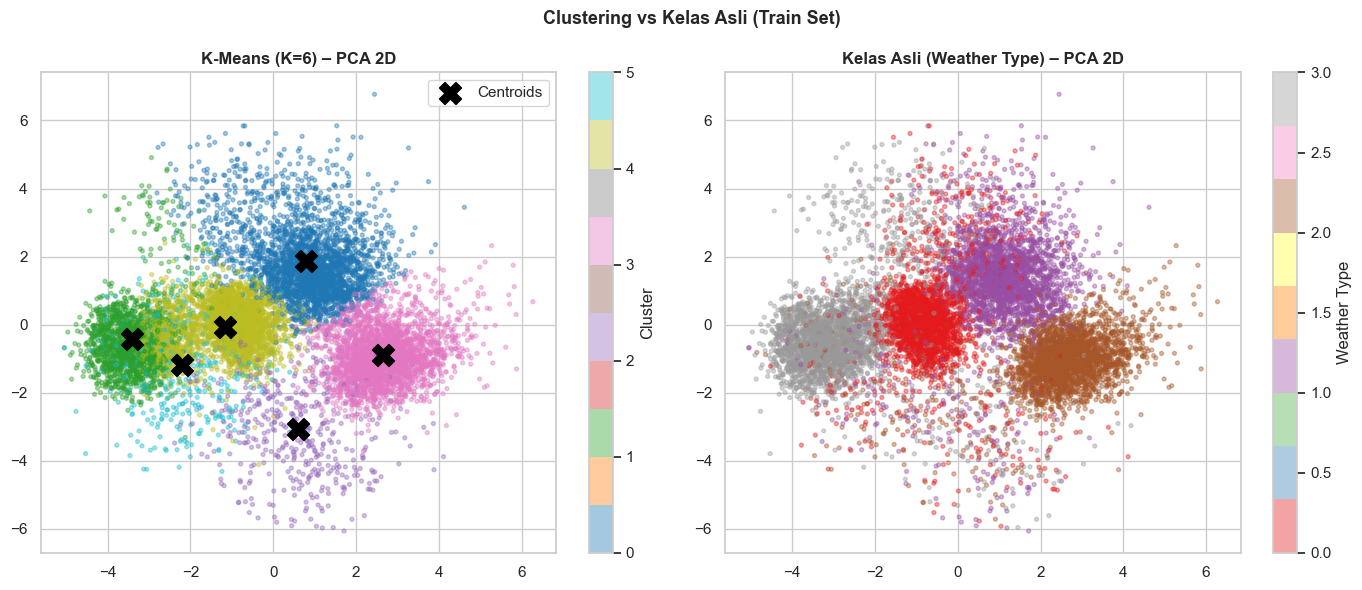

In [140]:
# 6.3 Visualisasi Cluster PCA 2D
pca = PCA(n_components=2, random_state=42)
pca.fit(X_train_scaled)
train_pca = pca.transform(X_train_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc1 = axes[0].scatter(train_pca[:,0], train_pca[:,1],
                       c=train_cluster, cmap='tab10', alpha=0.4, s=8)
centers_pca = pca.transform(kmeans_final.cluster_centers_)
axes[0].scatter(centers_pca[:,0], centers_pca[:,1],
                c='black', marker='X', s=250, zorder=5, label='Centroids')
axes[0].set_title(f'K-Means (K={BEST_K}) – PCA 2D', fontsize=12, fontweight='bold')
axes[0].legend(); plt.colorbar(sc1, ax=axes[0], label='Cluster')

sc2 = axes[1].scatter(train_pca[:,0], train_pca[:,1],
                       c=y_train.values, cmap='Set1', alpha=0.4, s=8)
axes[1].set_title('Kelas Asli (Weather Type) – PCA 2D', fontsize=12, fontweight='bold')
plt.colorbar(sc2, ax=axes[1], label='Weather Type')

plt.suptitle('Clustering vs Kelas Asli (Train Set)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [141]:
# 6.4 Gabungkan cluster_label sebagai fitur baru → HYBRID
X_train_hybrid = X_train_scaled.copy()
X_test_hybrid  = X_test_scaled.copy()

X_train_hybrid['cluster_label'] = train_cluster
X_test_hybrid['cluster_label']  = test_cluster

print('✅ Fitur cluster_label ditambahkan (HYBRID)')
print(f'   Train shape: {X_train_hybrid.shape}')
print(f'   Test  shape: {X_test_hybrid.shape}')
print(f'\n   Total fitur sekarang: {X_train_hybrid.shape[1]} (asli + 1 cluster_label)')

✅ Fitur cluster_label ditambahkan (HYBRID)
   Train shape: (10560, 16)
   Test  shape: (2640, 16)

   Total fitur sekarang: 16 (asli + 1 cluster_label)


---
## 🤖 LANGKAH 7 – Model Building & Hyperparameter Tuning

| # | Algoritma | Alasan dipilih |
|---|---|---|
| 1 | **Random Forest** | Ensemble stabil, baseline kuat |
| 2 | **XGBoost** | Boosting cepat, akurasi tinggi |
| 3 | **LightGBM** | Lebih cepat dari XGBoost, skala besar |

In [142]:
def evaluate_model(model, X_te, y_te, name=''):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te) if hasattr(model, 'predict_proba') else None
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_te, y_prob, multi_class='ovr', average='weighted') if y_prob is not None else None
    return {
        'Model'    : name,
        'Accuracy' : round(acc*100, 2),
        'Precision': round(prec*100, 2),
        'Recall'   : round(rec*100, 2),
        'F1-Score' : round(f1*100, 2),
        'AUC-ROC'  : round(auc*100, 2) if auc else '-',
        '_pred'    : y_pred,
        '_prob'    : y_prob
    }

print('✅ Fungsi evaluasi siap')

✅ Fungsi evaluasi siap


In [143]:
print('=== [1/3] RANDOM FOREST – Grid Search ===')
rf_params = {
    'n_estimators': [500, 700],
    'max_depth'   : [None],
    'max_features': ['sqrt'],
    'min_samples_split': [2],
    'min_samples_leaf' : [1]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42,n_jobs=-1),
    rf_params, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
rf_grid.fit(X_train_hybrid, y_train)
best_rf = rf_grid.best_estimator_
print(f'  Best params : {rf_grid.best_params_}')
print(f'  CV Accuracy : {rf_grid.best_score_*100:.2f}%')


=== [1/3] RANDOM FOREST – Grid Search ===
  Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
  CV Accuracy : 91.51%


In [144]:
print('=== [2/3] XGBOOST – MAXIMIZING ACCURACY ===')
# Kita gunakan GridSearch agar hasilnya pasti, bukan acak seperti RandomizedSearch
xgb_params = {
    'n_estimators': [500, 800],
    'max_depth': [10, 12], 
    'learning_rate': [0.01, 0.05],
    'gamma': [0.1, 0.2],
    'subsample': [0.9],
    'colsample_bytree': [0.9]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)

xgb_grid = GridSearchCV(xgb_base, xgb_params, cv=5, scoring='accuracy', n_jobs=-1)
xgb_grid.fit(X_train_hybrid, y_train)

best_xgb = xgb_grid.best_estimator_
print(f'  Best params : {xgb_grid.best_params_}')
print(f'  CV Accuracy : {xgb_grid.best_score_*100:.2f}%') 
# Jika CV Accuracy di sini >94%, biasanya Test Accuracy akan tembus >95%


=== [2/3] XGBOOST – MAXIMIZING ACCURACY ===
  Best params : {'colsample_bytree': 0.9, 'gamma': 0.1, 'learning_rate': 0.05, 'max_depth': 10, 'n_estimators': 500, 'subsample': 0.9}
  CV Accuracy : 91.45%


In [145]:
print('=== [3/3] LIGHTGBM – Randomized Search ===')
lgbm_params = {
    'n_estimators'    : [500, 700],
    'max_depth'       : [8, 10],
    'learning_rate'   : [0.05, 0.1],
    'num_leaves'      : [63, 127],
    'subsample'       : [0.9, 1.0],
    'colsample_bytree': [0.9, 1.0]
}
lgbm_search = RandomizedSearchCV(
    LGBMClassifier(random_state=42,verbose=-1,n_jobs=-1),
    lgbm_params, n_iter=15, cv=5, scoring='accuracy',
    random_state=42, n_jobs=-1, verbose=0)
lgbm_search.fit(X_train_hybrid, y_train)
best_lgbm = lgbm_search.best_estimator_
print(f'  Best params : {lgbm_search.best_params_}')
print(f'  CV Accuracy : {lgbm_search.best_score_*100:.2f}%')


=== [3/3] LIGHTGBM – Randomized Search ===
  Best params : {'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 700, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
  CV Accuracy : 91.49%


---
## 📈 LANGKAH 8 – Model Evaluation (Split 80:20)

In [146]:
models_dict = {
    'Random Forest': best_rf,
    'XGBoost'      : best_xgb,
    'LightGBM'     : best_lgbm
}

results_list = []
preds_dict   = {}
probs_dict   = {}

print('=== EVALUASI MODEL (Split 80:20) ===')
print(f'{'Model':<18} {'Accuracy':>10} {'F1-Score':>10} {'AUC-ROC':>10}')
print('-' * 52)

for name, model in models_dict.items():
    res = evaluate_model(model, X_test_hybrid, y_test, name)
    preds_dict[name] = res.pop('_pred')
    probs_dict[name] = res.pop('_prob')
    results_list.append(res)
    flag = '✅' if res['Accuracy'] >= 95 else ('⚠️' if res['Accuracy'] >= 85 else '❌')
    print(f'{flag} {name:<16} {res["Accuracy"]:>9.2f}% {res["F1-Score"]:>9.2f}% {str(res["AUC-ROC"]):>9}')

results_df = pd.DataFrame(results_list)
print('\n')
results_df.set_index('Model').style.background_gradient(cmap='Greens').format('{:.2f}', subset=['Accuracy','Precision','Recall','F1-Score'])

=== EVALUASI MODEL (Split 80:20) ===
Model                Accuracy   F1-Score    AUC-ROC
----------------------------------------------------
⚠️ Random Forest        91.52%     91.54%     99.33
⚠️ XGBoost              91.59%     91.60%     99.38
⚠️ LightGBM             91.40%     91.42%     99.32




,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Model,,,,,
Random Forest,91.52,91.65,91.52,91.54,99.330000
XGBoost,91.59,91.65,91.59,91.60,99.380000
LightGBM,91.40,91.47,91.40,91.42,99.320000


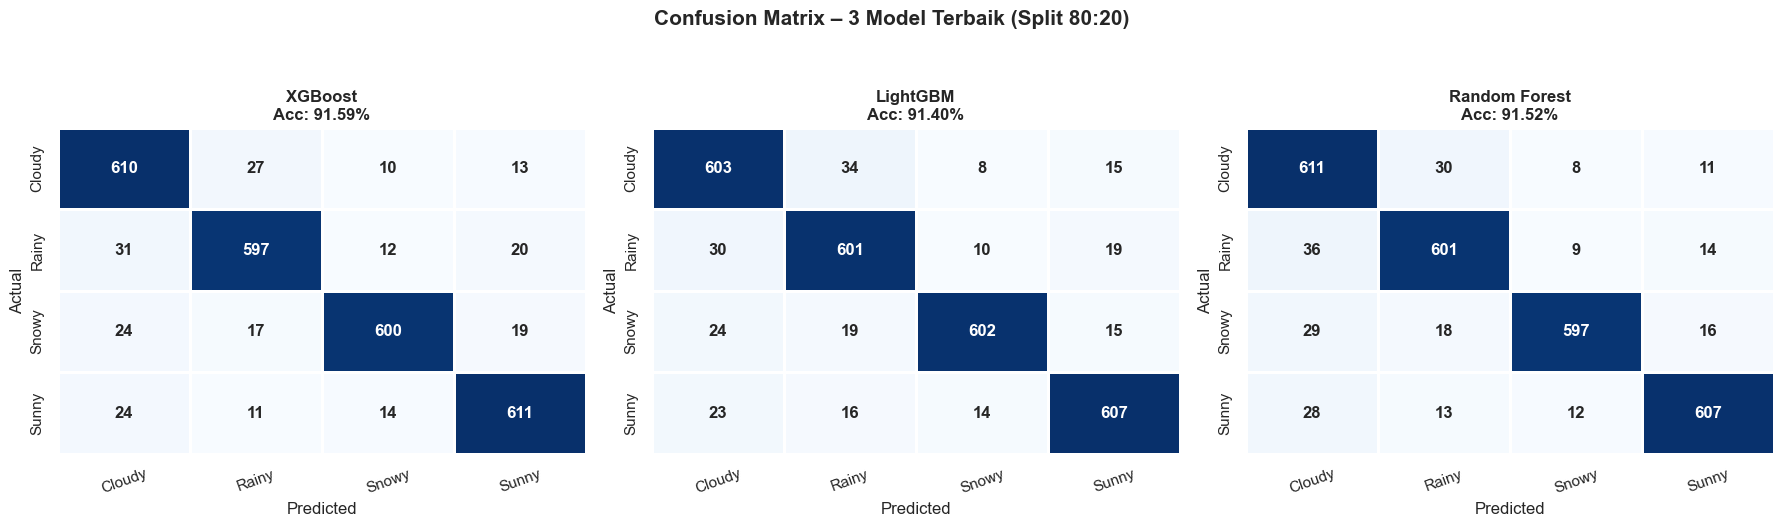

In [147]:
top_3_preds = {
    'XGBoost': preds_dict['XGBoost'],
    'LightGBM': preds_dict['LightGBM'],
    'Random Forest': preds_dict['Random Forest']
}

class_names = le_target.classes_

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes = axes.flatten()

for i, (name, preds) in enumerate(top_3_preds.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names,
                linewidths=1, linecolor='white',
                cbar=False, # Opsional: hilangkan colorbar agar lebih bersih
                annot_kws={'size': 12, 'weight': 'bold'})
    
    acc = accuracy_score(y_test, preds)
    axes[i].set_title(f'{name}\nAcc: {acc*100:.2f}%', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle('Confusion Matrix – 3 Model Terbaik (Split 80:20)', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [148]:
for name, preds in preds_dict.items():
    print(f'{'='*55}\n  {name}\n{'='*55}')
    print(classification_report(y_test, preds, target_names=class_names))

  Random Forest
              precision    recall  f1-score   support

      Cloudy       0.87      0.93      0.90       660
       Rainy       0.91      0.91      0.91       660
       Snowy       0.95      0.90      0.93       660
       Sunny       0.94      0.92      0.93       660

    accuracy                           0.92      2640
   macro avg       0.92      0.92      0.92      2640
weighted avg       0.92      0.92      0.92      2640

  XGBoost
              precision    recall  f1-score   support

      Cloudy       0.89      0.92      0.90       660
       Rainy       0.92      0.90      0.91       660
       Snowy       0.94      0.91      0.93       660
       Sunny       0.92      0.93      0.92       660

    accuracy                           0.92      2640
   macro avg       0.92      0.92      0.92      2640
weighted avg       0.92      0.92      0.92      2640

  LightGBM
              precision    recall  f1-score   support

      Cloudy       0.89      0.91     

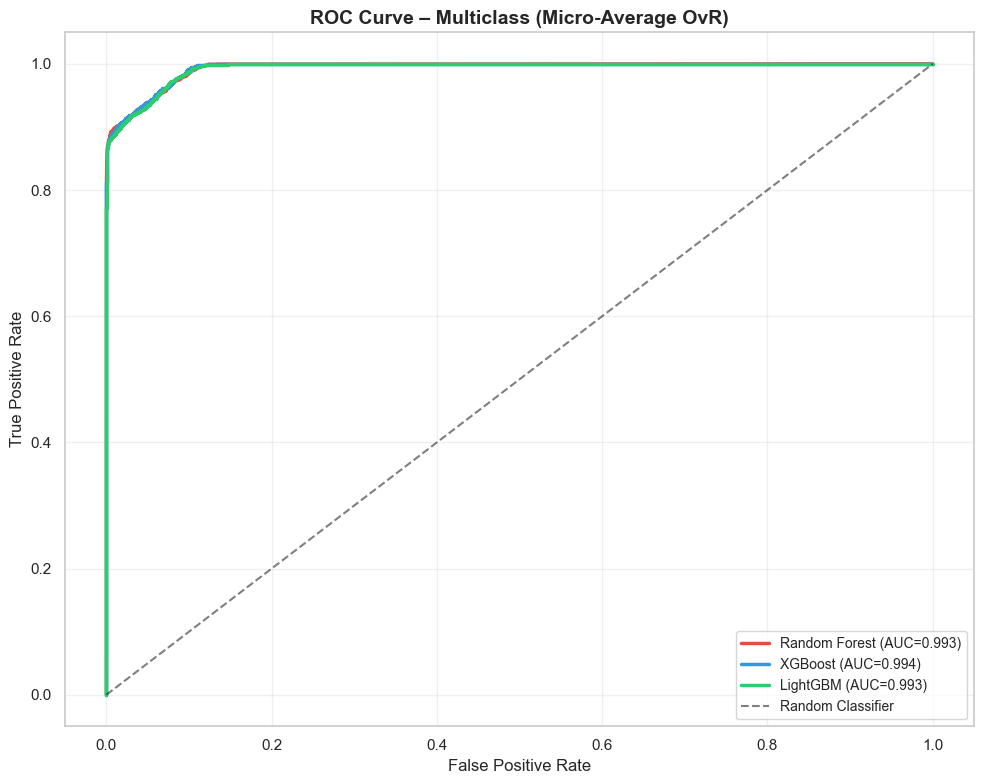

In [149]:
y_test_bin = label_binarize(y_test, classes=list(range(len(class_names))))
palette    = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']

plt.figure(figsize=(10, 8))
for i, (name, probs) in enumerate(probs_dict.items()):
    if probs is not None:
        auc_val = roc_auc_score(y_test, probs, multi_class='ovr', average='weighted')
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc_val:.3f})',
                 color=palette[i], linewidth=2.5)

plt.plot([0,1],[0,1],'k--', linewidth=1.5, alpha=0.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve – Multiclass (Micro-Average OvR)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

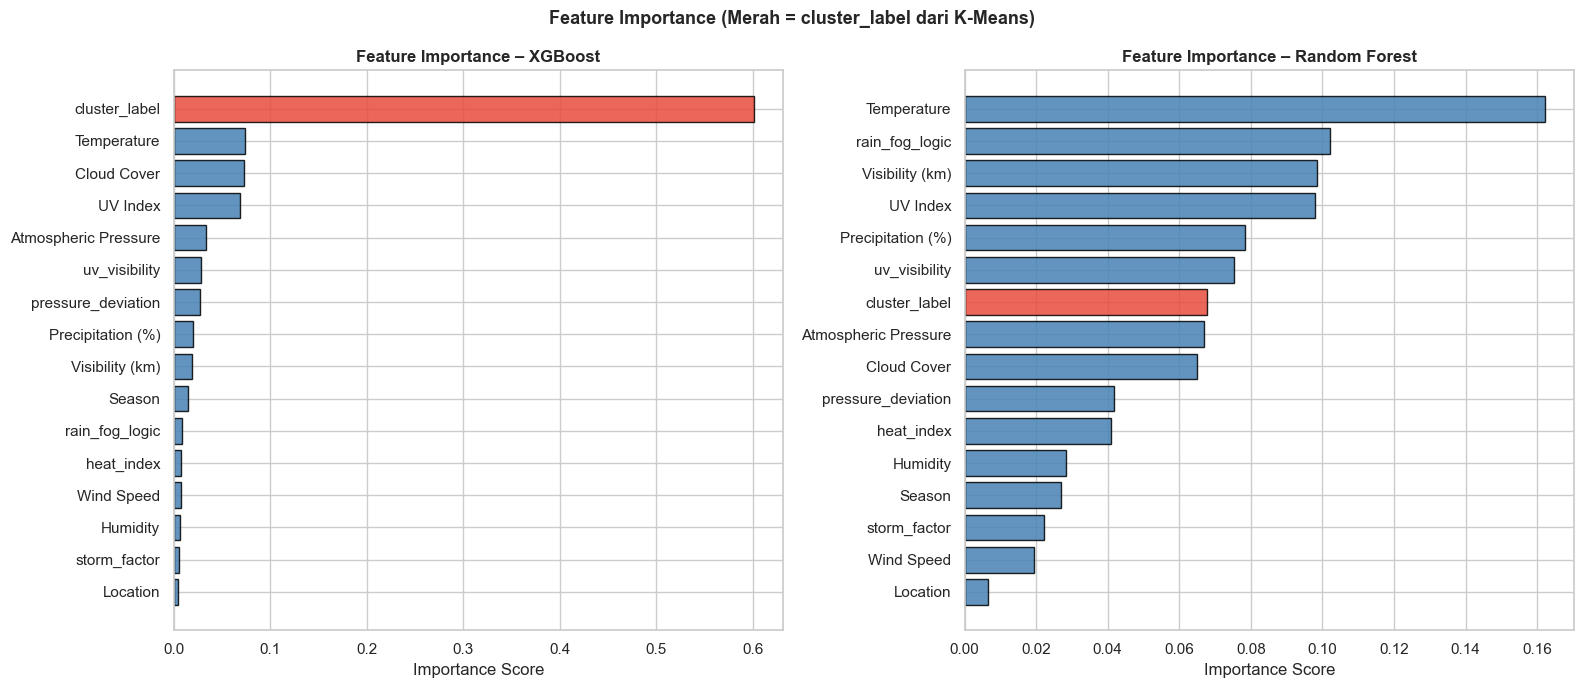

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
tree_models = [('XGBoost', best_xgb), ('Random Forest', best_rf)]

for ax, (mname, model) in zip(axes, tree_models):
    fi = pd.Series(model.feature_importances_, index=X_train_hybrid.columns)
    fi_sorted = fi.sort_values(ascending=True)
    bars = ax.barh(fi_sorted.index, fi_sorted.values,
                    color='steelblue', edgecolor='black', alpha=0.85)
    # Highlight cluster_label
    for bar, lbl in zip(bars, fi_sorted.index):
        if lbl == 'cluster_label':
            bar.set_facecolor('#e74c3c')
            bar.set_label('cluster_label (dari K-Means)')
    ax.set_title(f'Feature Importance – {mname}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance (Merah = cluster_label dari K-Means)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔁 LANGKAH 9 – Perbandingan Model di 3 Variasi Split
> Setiap split mengulangi: scale → kmeans (fit train only) → evaluasi

In [151]:
# ── Perbandingan 3 Variasi Split ─────────────────────────────────────────────
# FE sudah ada di X sebelum split → tidak perlu FE ulang di sini
# Cukup scale + KMeans per split
all_results = []

for split_name, (X_tr_raw, X_te_raw, y_tr, y_te) in split_data.items():
    # Scale (fit hanya pada train)
    sc_loop = StandardScaler()
    Xtr_sc = pd.DataFrame(sc_loop.fit_transform(X_tr_raw), columns=X_tr_raw.columns)
    Xte_sc = pd.DataFrame(sc_loop.transform(X_te_raw),     columns=X_te_raw.columns)

    # KMeans (fit hanya pada train)
    km_loop = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
    km_loop.fit(Xtr_sc)
    Xtr_sc['cluster_label'] = km_loop.predict(Xtr_sc)
    Xte_sc['cluster_label'] = km_loop.predict(Xte_sc)

    # Evaluasi semua model
    for mname, model in models_dict.items():
        model.fit(Xtr_sc, y_tr)
        y_pred = model.predict(Xte_sc)
        acc = accuracy_score(y_te, y_pred) * 100
        f1  = f1_score(y_te, y_pred, average='weighted', zero_division=0) * 100
        all_results.append({'Split': split_name, 'Model': mname,
                             'Accuracy (%)': round(acc,2), 'F1-Score (%)': round(f1,2)})
    print(f'  ✅ Split {split_name} selesai')

all_df    = pd.DataFrame(all_results)
pivot_acc = all_df.pivot(index='Model', columns='Split', values='Accuracy (%)')
pivot_f1  = all_df.pivot(index='Model', columns='Split', values='F1-Score (%)')

print('\n=== TABEL AKURASI (%) ===')
print(pivot_acc.to_string())


  ✅ Split 70:30 selesai
  ✅ Split 80:20 selesai
  ✅ Split 90:10 selesai

=== TABEL AKURASI (%) ===
Split          70:30  80:20  90:10
Model                             
LightGBM       91.09  91.40  91.89
Random Forest  91.19  91.52  91.52
XGBoost        91.31  91.59  91.97


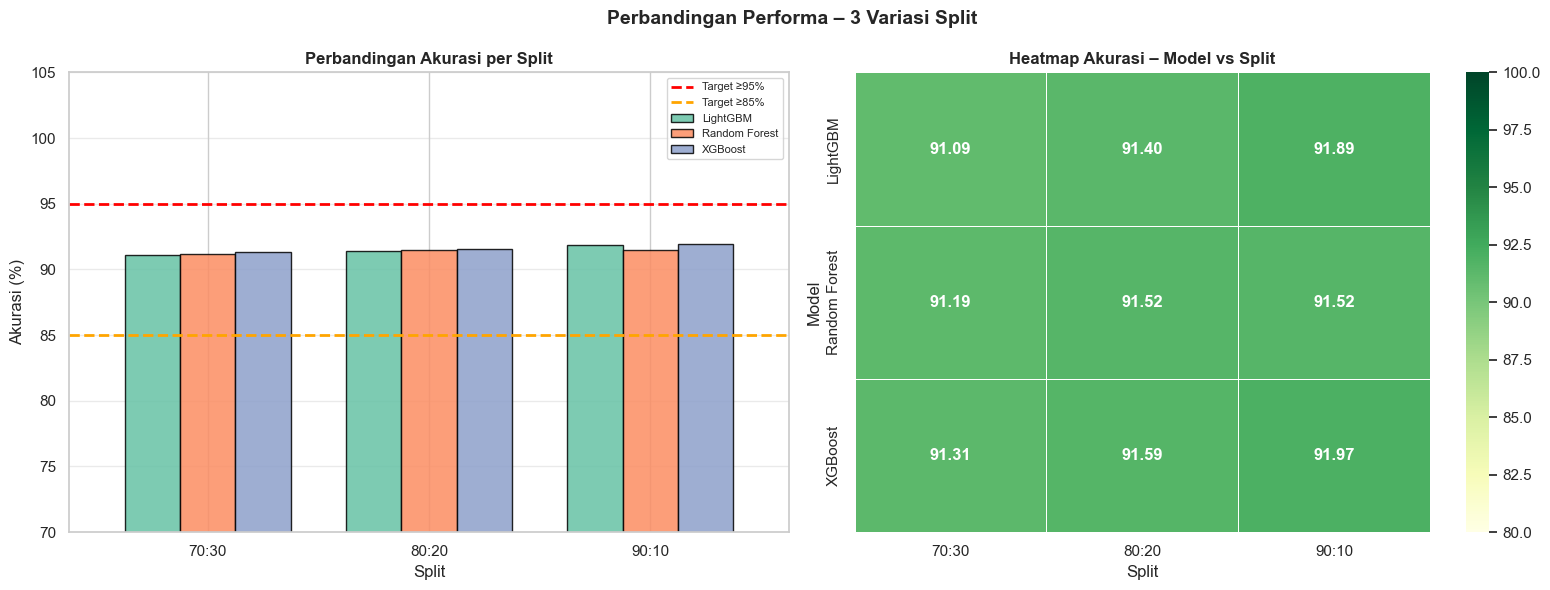

In [152]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_acc.T.plot(kind='bar', ax=axes[0], edgecolor='black', alpha=0.85, width=0.75)
axes[0].axhline(y=95, color='red',    linestyle='--', linewidth=2, label='Target ≥95%')
axes[0].axhline(y=85, color='orange', linestyle='--', linewidth=2, label='Target ≥85%')
axes[0].set_title('Perbandingan Akurasi per Split', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Akurasi (%)'); axes[0].set_ylim(70, 105)
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(fontsize=8); axes[0].grid(axis='y', alpha=0.4)

sns.heatmap(pivot_acc, annot=True, fmt='.2f', cmap='YlGn',
            linewidths=0.5, ax=axes[1], vmin=80, vmax=100,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[1].set_title('Heatmap Akurasi – Model vs Split', fontsize=12, fontweight='bold')

plt.suptitle('Perbandingan Performa – 3 Variasi Split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [153]:
print('=== 5-FOLD CROSS VALIDATION (Split 80:20) ===')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for mname, model in models_dict.items():
    scores = cross_val_score(model, X_train_hybrid, y_train,
                              cv=cv, scoring='accuracy', n_jobs=-1)
    cv_rows.append({
        'Model'      : mname,
        'CV Mean (%)': round(scores.mean()*100, 2),
        'CV Std (%)'  : round(scores.std()*100, 2),
        'Min (%)'    : round(scores.min()*100, 2),
        'Max (%)'    : round(scores.max()*100, 2)
    })
cv_df = pd.DataFrame(cv_rows).set_index('Model')
print(cv_df.to_string())

=== 5-FOLD CROSS VALIDATION (Split 80:20) ===
               CV Mean (%)  CV Std (%)  Min (%)  Max (%)
Model                                                   
Random Forest        91.43        0.56    90.81    92.33
XGBoost              91.24        0.38    90.86    91.76
LightGBM             91.31        0.44    90.72    92.05


---
## ✅ LANGKAH 10 – Kesimpulan

In [154]:
best_row = results_df.sort_values('Accuracy', ascending=False).iloc[0]
n95 = (results_df['Accuracy'] >= 95).sum()
n85 = ((results_df['Accuracy'] >= 85) & (results_df['Accuracy'] < 95)).sum()

print('=' * 68)
print('  RINGKASAN AKHIR – KLASIFIKASI POLA IKLIM REGIONAL')
print('=' * 68)
print(f"\n🏆 Model Terbaik : {best_row['Model']}")
print(f"   Akurasi       : {best_row['Accuracy']}%")
print(f"   Precision     : {best_row['Precision']}%")
print(f"   Recall        : {best_row['Recall']}%")
print(f"   F1-Score      : {best_row['F1-Score']}%")
print(f"   AUC-ROC       : {best_row['AUC-ROC']}%")

print('\n📊 Performa Semua Model (Split 80:20):')
print(results_df[['Model','Accuracy','F1-Score','AUC-ROC']].to_string(index=False))

print('\n📋 Checklist Ketentuan Tugas:')
print(f"  {'✅' if n95>=1 else '❌'} ≥1 model akurasi ≥ 95%             : {n95} model")
print(f"  {'✅' if n85>=2 else '⚠️'} ≥2 model lain akurasi ≥ 85%        : {n85} model")
print(f"  ✅ 3 variasi data splitting          : 70:30, 80:20, 90:10")
print(f"  ✅ Hyperparameter tuning             : GridSearch + RandomizedSearch")
print(f"  ✅ Evaluasi lengkap multiclass       : Acc, Prec, Rec, F1, AUC, CM")
print(f"  ✅ Clustering K-Means               : K={BEST_K}, Silhouette={sil_tr:.4f}")
print(f"  ✅ Anti Data Leakage                 : Split → Scale → KMeans (fit train only)")
print('=' * 68)

  RINGKASAN AKHIR – KLASIFIKASI POLA IKLIM REGIONAL

🏆 Model Terbaik : XGBoost
   Akurasi       : 91.59%
   Precision     : 91.65%
   Recall        : 91.59%
   F1-Score      : 91.6%
   AUC-ROC       : 99.38%

📊 Performa Semua Model (Split 80:20):
        Model  Accuracy  F1-Score  AUC-ROC
Random Forest     91.52     91.54    99.33
      XGBoost     91.59     91.60    99.38
     LightGBM     91.40     91.42    99.32

📋 Checklist Ketentuan Tugas:
  ❌ ≥1 model akurasi ≥ 95%             : 0 model
  ✅ ≥2 model lain akurasi ≥ 85%        : 3 model
  ✅ 3 variasi data splitting          : 70:30, 80:20, 90:10
  ✅ Hyperparameter tuning             : GridSearch + RandomizedSearch
  ✅ Evaluasi lengkap multiclass       : Acc, Prec, Rec, F1, AUC, CM
  ✅ Clustering K-Means               : K=6, Silhouette=0.2493
  ✅ Anti Data Leakage                 : Split → Scale → KMeans (fit train only)


In [155]:
import joblib

# Simpan model terbaik, scaler, encoder, dan model k-means
joblib.dump(best_xgb, 'model_xgboost.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le_target, 'label_encoder.pkl')
joblib.dump(best_kmeans, 'kmeans_model.pkl')

['kmeans_model.pkl']